# Social Media Donations — Real Data Pipeline

This notebook replaces the synthetic social-media pipeline with real Lighthouse data.  
It predicts whether a social media post leads to donations and estimates donation value attributable to a post.

## 1. Load real data

This notebook first tries the same database-style pattern used in your other notebooks:

- `importTableFromDb("dbo.social_media_posts")`
- `importTableFromDb("dbo.donations")`
- `importTableFromDb("dbo.supporters")`

If that helper is unavailable, it falls back to `lighthouse_csv_v7.zip`.

In [1]:
from pathlib import Path
import zipfile
import io
import os
import warnings

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from pythondbconnection import importTableFromDb

social_media_posts = importTableFromDb("dbo.social_media_posts")
donations = importTableFromDb("dbo.donations")
supporters = importTableFromDb("dbo.supporters")

print("social_media_posts:", social_media_posts.shape)
print("donations:", donations.shape)
print("supporters:", supporters.shape)
display(social_media_posts.head(3))
display(donations.head(3))

social_media_posts: (812, 39)
donations: (420, 14)
supporters: (60, 15)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,1,YouTube,yt_4770130763707641,https://youtube.com/watch?v=4Ohc0jdwK7o,2024-12-03 12:35:00,Tuesday,12,EducationalContent,Video,The statistics are heartbreaking. The solution...,...,5170.0,0.0543,63,0,0.00,399,310200.0,60.0,500.0,NaN
1,2,TikTok,tk_2835255890128396,https://tiktok.com/@lighthouse_ph/video/600647...,2024-03-30 19:09:00,Saturday,19,ThankYou,Carousel,Every donation is a prayer answered. Thank you...,...,NaN,0.1391,48,0,0.00,469,NaN,NaN,NaN,NaN
2,3,Twitter,tw_8792828008998924,https://twitter.com/lighthouse_ph/status/92646...,2023-09-29 18:31:00,Friday,18,Campaign,Text,Join our Summer of Safety campaign! Every peso...,...,NaN,0.2404,219,11,22188.01,522,NaN,NaN,NaN,NaN


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,created_by_partner_id,referral_post_id
0,1,42,Monetary,2025-12-31,False,None,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,None,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,None,NaN,35.15,hours,Community outreach support,None,NaN
2,3,19,Monetary,2024-12-02,False,None,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,None,NaN


## 2. Prepare the post-level modeling table

We use **one row per social media post**.

### Targets
- `post_generated_donation`: whether the post led to at least one attributed donation
- `donations_amount_php`: total donated amount attributed to that post

The strongest real-world attribution in this dataset is `donations.referral_post_id -> social_media_posts.post_id`.

In [2]:
posts = social_media_posts.copy()
don = donations.copy()
sup = supporters.copy()

# Standardize dates
posts["created_at"] = pd.to_datetime(posts["created_at"], errors="coerce")
don["donation_date"] = pd.to_datetime(don["donation_date"], errors="coerce")
sup["created_at"] = pd.to_datetime(sup.get("created_at"), errors="coerce")
if "first_donation_date" in sup.columns:
    sup["first_donation_date"] = pd.to_datetime(sup["first_donation_date"], errors="coerce")

# Clean key columns
posts["post_id"] = pd.to_numeric(posts["post_id"], errors="coerce")
don["referral_post_id"] = pd.to_numeric(don["referral_post_id"], errors="coerce")
don["supporter_id"] = pd.to_numeric(don["supporter_id"], errors="coerce")

# Aggregate attributed donations by post
don["amount_php"] = pd.to_numeric(don.get("amount"), errors="coerce").fillna(0.0)

post_don_agg = (
    don.dropna(subset=["referral_post_id"])
      .groupby("referral_post_id")
      .agg(
          donations_count=("donation_id", "count"),
          donations_amount_php=("amount_php", "sum"),
          unique_donors=("supporter_id", pd.Series.nunique),
      )
      .reset_index()
      .rename(columns={"referral_post_id": "post_id"})
)

df = posts.merge(post_don_agg, on="post_id", how="left")
for col in ["donations_count", "donations_amount_php", "unique_donors"]:
    df[col] = df[col].fillna(0)

df["post_generated_donation"] = (df["donations_count"] > 0).astype(int)

# Basic text features
df["caption"] = df["caption"].fillna("")
df["caption_length_calc"] = df["caption"].str.len()
df["num_words"] = df["caption"].str.split().str.len().fillna(0)
df["has_question"] = df["caption"].str.contains(r"\?", regex=True).fillna(False).astype(int)
df["has_link"] = df["caption"].str.contains(r"http|www\.", case=False, regex=True).fillna(False).astype(int)

# Standardize booleans
bool_cols = ["has_call_to_action", "features_resident_story", "is_boosted"]
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].astype("boolean")

# Fill numeric engagement features if present
numeric_candidates = [
    "post_hour", "num_hashtags", "mentions_count", "caption_length", "caption_length_calc", "num_words",
    "boost_budget_php", "impressions", "reach", "likes", "comments", "shares", "saves", "click_throughs",
    "video_views", "engagement_rate", "profile_visits", "follower_count_at_post", "watch_time_seconds",
    "avg_view_duration_seconds", "subscriber_count_at_post", "forwards"
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

display(df[["post_id", "platform", "post_type", "created_at", "donations_count", "donations_amount_php", "post_generated_donation"]].head())
print(df["post_generated_donation"].value_counts(dropna=False))

,post_id,platform,post_type,created_at,donations_count,donations_amount_php,post_generated_donation
0,1,YouTube,EducationalContent,2024-12-03 12:35:00,0.0,0.0,0
1,2,TikTok,ThankYou,2024-03-30 19:09:00,0.0,0.0,0
2,3,Twitter,Campaign,2023-09-29 18:31:00,0.0,0.0,0
3,4,Instagram,FundraisingAppeal,2024-05-02 13:17:00,0.0,0.0,0
4,5,LinkedIn,ImpactStory,2025-06-08 16:50:00,0.0,0.0,0


post_generated_donation
0    750
1     62
Name: count, dtype: int64


## 3. Feature selection and train/test split

We exclude direct leakage columns like:
- `donation_referrals`
- `estimated_donation_value_php`
- the target columns themselves

This gives us a cleaner post-performance prediction setup.

In [3]:
from sklearn.model_selection import train_test_split

TARGET_CLS = "post_generated_donation"
TARGET_REG = "donations_amount_php"

leakage_cols = {
    "post_id",
    "platform_post_id",
    "post_url",
    "donation_referrals",            # near-direct outcome
    "estimated_donation_value_php",  # near-direct outcome
    TARGET_CLS,
    TARGET_REG,
    "donations_count",
    "unique_donors",
}

feature_cols = [c for c in df.columns if c not in leakage_cols]

X = df[feature_cols].copy()
y_cls = df[TARGET_CLS].copy()
y_reg = df[TARGET_REG].copy()

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Positive rate (train):", round(y_cls_train.mean(), 4))
print("Positive rate (test):", round(y_cls_test.mean(), 4))

Train shape: (649, 38)
Test shape: (163, 38)
Positive rate (train): 0.077
Positive rate (test): 0.0736


## 4. Exploratory plots

These plots help show the relationship between post engagement and donation outcomes.

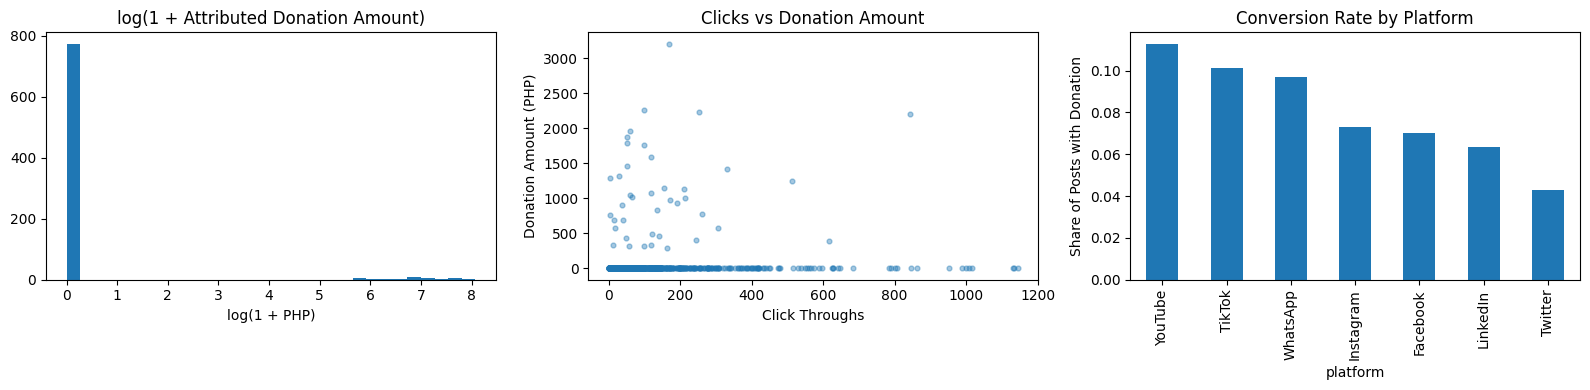

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(np.log1p(df["donations_amount_php"]), bins=30)
axes[0].set_title("log(1 + Attributed Donation Amount)")
axes[0].set_xlabel("log(1 + PHP)")

if "click_throughs" in df.columns:
    axes[1].scatter(df["click_throughs"].fillna(0), df["donations_amount_php"], alpha=0.4, s=12)
    axes[1].set_xlabel("Click Throughs")
    axes[1].set_ylabel("Donation Amount (PHP)")
    axes[1].set_title("Clicks vs Donation Amount")
else:
    axes[1].text(0.5, 0.5, "click_throughs not available", ha="center", va="center")
    axes[1].set_axis_off()

df.groupby("platform")[TARGET_CLS].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[2])
axes[2].set_title("Conversion Rate by Platform")
axes[2].set_ylabel("Share of Posts with Donation")

plt.tight_layout()
plt.show()

## 5. Preprocessing

We use a `ColumnTransformer` so numeric and categorical variables are handled safely.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(include=[np.number, "bool", "boolean"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer_for_logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_for_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_for_logreg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_for_logreg, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor_for_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_for_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 27
Categorical features: 11


## 6. Modeling

We fit:
- a **classification model** for whether a post converts to a donation
- a **regression model** for donation amount attributable to the post

This mirrors the intent of the original notebook, but now uses real data.

In [6]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = {
    "Balanced Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_for_logreg),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            C=0.7,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Balanced Random Forest": Pipeline([
        ("preprocessor", preprocessor_for_tree),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
    "Balanced Extra Trees": Pipeline([
        ("preprocessor", preprocessor_for_tree),
        ("model", ExtraTreesClassifier(
            n_estimators=600,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, pipe in models.items():
    roc = cross_val_score(pipe, X_train, y_cls_train, cv=cv, scoring="roc_auc").mean()
    ap = cross_val_score(pipe, X_train, y_cls_train, cv=cv, scoring="average_precision").mean()
    results.append({"model": name, "cv_roc_auc": roc, "cv_ap": ap})

results_df = pd.DataFrame(results).sort_values(["cv_roc_auc", "cv_ap"], ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_cls_train)

best_model_name

,model,cv_roc_auc,cv_ap
1,Balanced Random Forest,0.711854,0.213827
2,Balanced Extra Trees,0.691076,0.151303
0,Balanced Logistic Regression,0.659532,0.145601


'Balanced Random Forest'

## 7. Threshold tuning

We tune the classification threshold to better balance precision and recall.

In [7]:
from sklearn.metrics import precision_recall_curve

y_proba_valid = best_pipe.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_cls_test, y_proba_valid)

f1_scores = []
for p, r in zip(precision[:-1], recall[:-1]):
    f1_scores.append(0 if (p + r) == 0 else 2 * p * r / (p + r))

best_idx = int(np.argmax(f1_scores)) if len(f1_scores) else 0
best_threshold = float(thresholds[best_idx]) if len(thresholds) else 0.5

print("Best threshold:", round(best_threshold, 4))
print("Best threshold F1:", round(f1_scores[best_idx], 4) if len(f1_scores) else np.nan)

Best threshold: 0.2818
Best threshold F1: 0.198


## 8. Final classification evaluation

This section reports ROC-AUC, Average Precision, classification metrics, and plots.

Best model: Balanced Random Forest
ROC-AUC: 0.6109
Average Precision: 0.1118

              precision    recall  f1-score   support

 No Donation       0.97      0.48      0.64       151
    Donation       0.11      0.83      0.20        12

    accuracy                           0.50       163
   macro avg       0.54      0.66      0.42       163
weighted avg       0.91      0.50      0.61       163



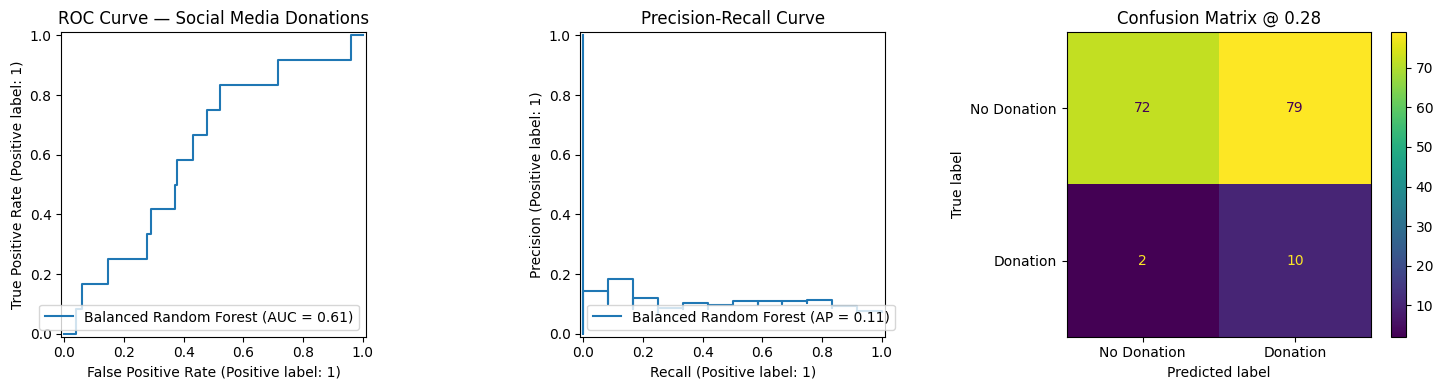

In [8]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

print("Best model:", best_model_name)
print("ROC-AUC:", round(roc_auc_score(y_cls_test, y_proba) if y_cls_test.nunique() > 1 else np.nan, 4))
print("Average Precision:", round(average_precision_score(y_cls_test, y_proba), 4))
print()
print(classification_report(y_cls_test, y_pred, target_names=["No Donation", "Donation"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_predictions(y_cls_test, y_proba, ax=axes[0], name=best_model_name)
axes[0].set_title("ROC Curve — Social Media Donations")

PrecisionRecallDisplay.from_predictions(y_cls_test, y_proba, ax=axes[1], name=best_model_name)
axes[1].set_title("Precision-Recall Curve")

ConfusionMatrixDisplay.from_predictions(
    y_cls_test, y_pred, display_labels=["No Donation", "Donation"], ax=axes[2]
)
axes[2].set_title(f"Confusion Matrix @ {best_threshold:.2f}")

plt.tight_layout()
plt.show()

## 9. Donation amount regression (secondary task)

We also estimate the donation amount attributable to a post.  
This is a secondary analysis and may be noisier than the conversion model.

In [9]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

reg_pipe = Pipeline([
    ("preprocessor", preprocessor_for_tree),
    ("model", GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    )),
])

y_reg_train_log = np.log1p(y_reg_train)
y_reg_test_log = np.log1p(y_reg_test)

reg_pipe.fit(X_train, y_reg_train_log)
y_pred_log = reg_pipe.predict(X_test)
y_pred_amount = np.expm1(y_pred_log)

r2 = r2_score(y_reg_test_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_reg_test_log, y_pred_log))
rmse_php = np.sqrt(mean_squared_error(y_reg_test, y_pred_amount))

print(f"Regression — R² (log): {r2:.4f}")
print(f"Regression — RMSE (log): {rmse_log:.4f}")
print(f"Regression — RMSE (PHP): {rmse_php:.2f}")

Regression — R² (log): -0.0005
Regression — RMSE (log): 1.3876
Regression — RMSE (PHP): 310.05


## 10. Feature importance

This helps explain which post features are driving donation outcomes.

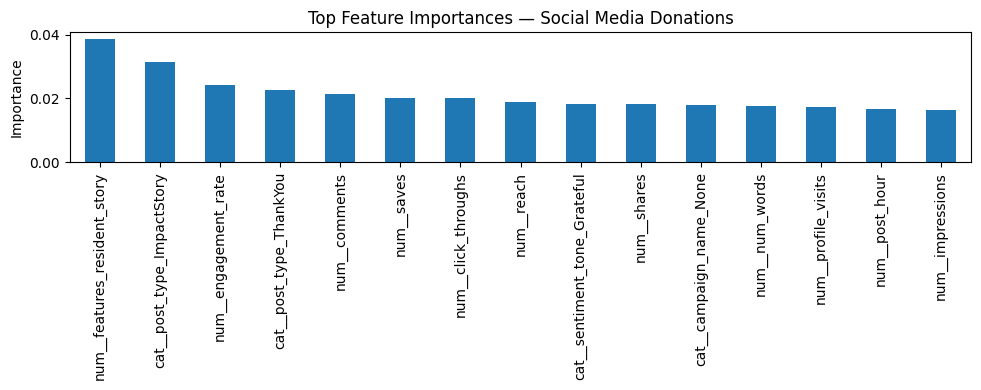

Top engineered / raw predictors shown above.


In [10]:
# Fit an interpretable tree model for feature importances
tree_for_importance = Pipeline([
    ("preprocessor", preprocessor_for_tree),
    ("model", ExtraTreesClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
    )),
])
tree_for_importance.fit(X_train, y_cls_train)

pre = tree_for_importance.named_steps["preprocessor"]
model = tree_for_importance.named_steps["model"]

feature_names = pre.get_feature_names_out()
importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
importances.head(15).plot(kind="bar")
plt.title("Top Feature Importances — Social Media Donations")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

selected_features = list(X_train.columns)
print("Top engineered / raw predictors shown above.")

## 11. Save the final model

This follows the same standardized save pattern used in your other pipelines.

In [11]:
import os
import pickle

os.makedirs("models", exist_ok=True)

selected_features = list(X_train.columns)
classification_model = best_pipe
regression_model = reg_pipe

classification_model_path = "models/social_media_donations_classification_model.pkl"
regression_model_path = "models/social_media_donations_regression_model.pkl"

with open(classification_model_path, "wb") as f:
    pickle.dump({
        "model": classification_model,
        "features": selected_features,
        "threshold": best_threshold if 'best_threshold' in globals() else 0.5,
        "target_name": "post_generated_donation",
        "task": "classification",
    }, f)

with open(regression_model_path, "wb") as f:
    pickle.dump({
        "model": regression_model,
        "features": selected_features,
        "target_name": "donations_amount_php",
        "task": "regression",
        "target_transform": "log1p",
    }, f)

print(f"Classification model saved to {classification_model_path}")
print(f"Regression model saved to {regression_model_path}")

new_posts = X_test[selected_features].iloc[:5].copy()
probs = classification_model.predict_proba(new_posts)[:, 1]
pred_log = regression_model.predict(new_posts)
pred_amount_php = np.expm1(pred_log)

new_posts["donation_probability"] = probs
new_posts["prediction"] = (probs >= (best_threshold if 'best_threshold' in globals() else 0.5)).astype(int)
new_posts["predicted_amount_php"] = pred_amount_php.round(2)

new_posts["impact_tier"] = pd.cut(
    new_posts["donation_probability"],
    bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

print(new_posts[["donation_probability", "prediction", "predicted_amount_php", "impact_tier"]])

Classification model saved to models/social_media_donations_classification_model.pkl
Regression model saved to models/social_media_donations_regression_model.pkl
     donation_probability  prediction  predicted_amount_php impact_tier
460              0.349136           1                  0.08         Low
759              0.283011           1                  0.08         Low
800              0.202074           0                  0.08         Low
532              0.202568           0                  0.08         Low
407              0.242757           0                  0.08         Low


## 12. Stakeholder summary

This pipeline predicts which social media posts are most likely to generate donations by analyzing platform, content, and engagement patterns. It helps prioritize content strategy, identify high-impact post characteristics, and support more data-driven fundraising decisions.